
# Causal Inference for Economics: Does Job Training Raise Wages?

**A hands-on project based on Chapter 1 of *Causal Inference for Data Science*
(De Villa, Manning, 2025)**

In this notebook we apply the core ideas from Chapter 1 — confounding,
the difference between observational and experimental data, spurious
correlation, the average treatment effect (ATE), and conditional
expectations — to a classic economics question:

> **Does participating in a government job-training program cause an increase
> in earnings?**

This is one of the most famous problems in applied econometrics (it's the
setting of LaLonde's 1986 study and the Angrist/Imbens/Rubin literature the
book references). We'll build our intuition with **synthetic data** first
(so we know the "ground truth," just like the book recommends in section
1.4.1), and then apply the same reasoning template to a pattern you'd see
in real labor-market data.

### What you'll practice
1. Simulating **observational data** with a confounder (steps 1–2 of the
   book's 5-step causal workflow)
2. Seeing how a naive comparison of means gives a **biased** estimate of
   the treatment effect
3. Using **stratification / the adjustment idea** to remove confounding bias
4. Simulating a **randomized controlled trial (RCT)** as the "gold standard"
   benchmark and confirming randomization removes confounding
5. A **spurious correlation** demo, economics-flavored
6. Conditional expectations, `E[Y|X]`, computed directly from data
7. Exercises to extend the project


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(1234)
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3



## 1. The scenario

You work for a labor-economics research team. A job-training program
(think: a subsidized skills-training course) has been running for a while.
Program staff enrolled people based on their judgment of who needed it
most — mostly people with **weaker recent labor-market attachment**
(fewer years of work experience). We only have **observational data**:
who chose/was chosen for the program, and their earnings a year later.

Naturally, people with less experience tend to earn less *regardless* of
training. So `experience` is a **confounder**: it affects both

- whether someone enrolls in the program (`Treatment`), and
- their earnings (`Outcome`)

This is exactly the DAG from Figure 1.7 of the book:

```
        Confounder (experience)
           /              \
          v                v
    Treatment (program) --> Outcome (earnings)
```

If we naively compare average earnings of trainees vs. non-trainees, we
risk confusing "the program doesn't help much" with "people with less
experience earn less no matter what."



## 2. Step 1–2 of the causal workflow: build a synthetic data-generating process

Following section 1.4.1 of the book, we simulate data ourselves so that we
*know* the true causal effect. This lets us check whether our causal
inference methods recover the truth — like practicing in the shallow end
of the pool before swimming in open water.

**True data-generating process (hidden from the analyst in real life):**

- `experience` (years of prior work experience): drives both training
  enrollment and earnings.
- `treatment` (1 = enrolled in job training, 0 = did not): people with
  *less* experience are more likely to be selected into the program.
- `earnings` (thousands of $ / year, one year after the program): driven by
  experience **and** a true causal bump from the training program of
  **+3 (thousand dollars)** on average — this is the number we're trying to recover.


In [2]:

n = 5000

# Confounder: years of experience (0-20)
experience = np.random.uniform(0, 20, size=n)

# Treatment assignment is NOT random: people with less experience are
# more likely to be enrolled in the program (selection into treatment)
prob_treatment = 1 / (1 + np.exp(0.25 * (experience - 10)))  # logistic
treatment = np.random.binomial(1, prob_treatment)

# True causal effect of the program on earnings is +3 (thousand $/year)
TRUE_ATE = 3.0

# Outcome: driven by experience (confounder) + true treatment effect + noise
earnings = (
    20                      # base earnings
    + 1.4 * experience      # more experience -> higher pay
    + TRUE_ATE * treatment  # <-- the causal effect we want to recover
    + np.random.normal(0, 4, size=n)  # noise
)

obs = pd.DataFrame({
    'experience': experience,
    'treatment': treatment,
    'earnings': earnings
})
obs.head()


,experience,treatment,earnings
0,3.830389,0,27.651148
1,12.442175,0,44.107287
2,8.754555,1,39.907711
3,15.707172,0,45.100745
4,15.599516,0,42.894578



## 3. The naive (biased) comparison

Let's do what many analysts do first: just compare the average earnings of
the treated group vs. the control group. This is a **conditional
expectation**, `E[earnings | treatment]` — exactly the notion introduced in
section 1.5.2 of the book.


In [3]:

naive_treated = obs.loc[obs.treatment == 1, 'earnings'].mean()
naive_control = obs.loc[obs.treatment == 0, 'earnings'].mean()
naive_ate = naive_treated - naive_control

print(f"E[earnings | treatment=1] = {naive_treated:.2f}")
print(f"E[earnings | treatment=0] = {naive_control:.2f}")
print(f"Naive difference (biased 'ATE') = {naive_ate:.2f}")
print(f"True ATE (by construction)      = {TRUE_ATE:.2f}")


E[earnings | treatment=1] = 32.23
E[earnings | treatment=0] = 38.51
Naive difference (biased 'ATE') = -6.27
True ATE (by construction)      = 3.00



The naive difference is **far from the true effect of +3**, and its sign
might even be wrong or misleadingly small — because people in the program
had *less* experience to begin with, which drags their average earnings
down independently of the program's effect. This is the "Correlation is
not causation" problem from section 1.4, applied to a real economic policy
question: without adjustment, you might wrongly conclude the training
program doesn't work (or even hurts earnings).


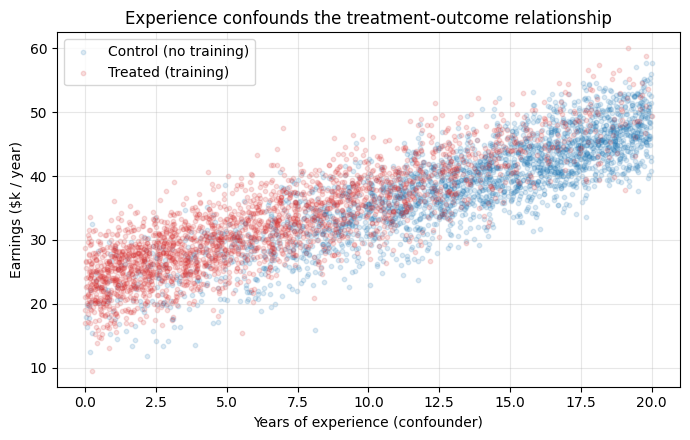

In [4]:

fig, ax = plt.subplots()
for t, color, label in [(0, '#1f77b4', 'Control (no training)'),
                          (1, '#d62728', 'Treated (training)')]:
    subset = obs[obs.treatment == t]
    ax.scatter(subset.experience, subset.earnings, alpha=0.15, s=10,
               color=color, label=label)

ax.set_xlabel('Years of experience (confounder)')
ax.set_ylabel('Earnings ($k / year)')
ax.set_title('Experience confounds the treatment-outcome relationship')
ax.legend()
plt.tight_layout()
plt.show()



Notice the treated group (red) is concentrated at **low experience**, and
the control group (blue) at **high experience**. That's the selection
bias visualized: the groups aren't comparable on their own.



## 4. Adjusting for the confounder (the idea behind the adjustment formula)

The book previews the **adjustment formula** (fully derived in chapter 2)
as the tool for removing confounding bias. The intuition, which we can
apply right now with simple stratification, is:

> Compare treated vs. control **within narrow bands of the confounder**,
> then average those within-band effects back up to the full population.

This mimics comparing "apples to apples" — people with similar experience
levels, some of whom happened to get training and some who didn't.


In [5]:

# Stratify experience into bins ("apples to apples" comparison)
obs['exp_bin'] = pd.cut(obs.experience, bins=10)

strata = (
    obs.groupby('exp_bin', observed=True)
       .apply(lambda d: pd.Series({
           'n': len(d),
           'mean_treated': d.loc[d.treatment == 1, 'earnings'].mean(),
           'mean_control': d.loc[d.treatment == 0, 'earnings'].mean(),
       }), include_groups=False)
)
strata['effect'] = strata['mean_treated'] - strata['mean_control']
strata


,n,mean_treated,mean_control,effect
exp_bin,,,,
"(-0.0195, 2.0]",537.0,24.487350,21.756008,2.731342
"(2.0, 4.0]",516.0,27.136796,23.761885,3.374911
"(4.0, 6.0]",453.0,30.067632,27.484927,2.582705
"(6.0, 8.0]",462.0,33.062586,29.782265,3.280321
"(8.0, 10.0]",491.0,35.550834,32.730532,2.820302
"(10.0, 12.0]",546.0,37.588024,35.633562,1.954463
"(12.0, 14.0]",494.0,40.932904,38.126195,2.806708
"(14.0, 16.0]",490.0,43.540605,41.069969,2.470635
"(16.0, 17.999]",522.0,47.360429,43.855605,3.504823


In [6]:

# Adjustment formula (simplified, stratified version):
# weight each stratum's effect by its share of the population
adjusted_ate = np.average(strata['effect'].dropna(),
                           weights=strata.loc[strata['effect'].notna(), 'n'])

print(f"Naive (unadjusted) difference = {naive_ate:.2f}")
print(f"Adjusted (stratified) ATE     = {adjusted_ate:.2f}")
print(f"True ATE                      = {TRUE_ATE:.2f}")


Naive (unadjusted) difference = -6.27
Adjusted (stratified) ATE     = 2.77
True ATE                      = 3.00



Adjusting for the confounder brings our estimate **much closer to the true
effect of +3**. This is a simplified, intuitive version of the adjustment
formula the book develops formally in chapter 2 (there, it's usually done
with regression or matching rather than manual binning, which is more
efficient and doesn't throw away information at bin edges — but the logic
is identical).



## 5. The gold standard: simulate what an RCT / A/B test would show

Section 1.3 of the book explains why randomized controlled trials (RCTs) —
called A/B tests outside economics — are the gold standard: **random
assignment breaks the link between the confounder and the treatment**, so
no adjustment is needed at all.

Let's simulate the *same* population, but imagine the program had instead
been rolled out as a proper RCT: enrollment assigned by a coin flip,
independent of experience.


In [7]:

# Same experience distribution, but treatment assigned purely at random
np.random.seed(42)
experience_rct = np.random.uniform(0, 20, size=n)
treatment_rct = np.random.binomial(1, 0.5, size=n)  # <-- coin flip, no confounding

earnings_rct = (
    20
    + 1.4 * experience_rct
    + TRUE_ATE * treatment_rct
    + np.random.normal(0, 4, size=n)
)

rct = pd.DataFrame({
    'experience': experience_rct,
    'treatment': treatment_rct,
    'earnings': earnings_rct
})

rct_ate = (rct.loc[rct.treatment == 1, 'earnings'].mean()
           - rct.loc[rct.treatment == 0, 'earnings'].mean())

print(f"RCT difference in means (no adjustment needed) = {rct_ate:.2f}")
print(f"True ATE                                        = {TRUE_ATE:.2f}")


RCT difference in means (no adjustment needed) = 3.10
True ATE                                        = 3.00


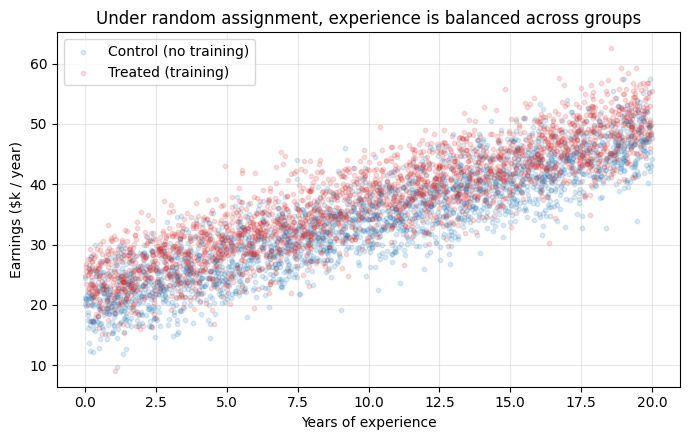

In [8]:

fig, ax = plt.subplots()
for t, color, label in [(0, '#1f77b4', 'Control (no training)'),
                          (1, '#d62728', 'Treated (training)')]:
    subset = rct[rct.treatment == t]
    ax.scatter(subset.experience, subset.earnings, alpha=0.15, s=10,
               color=color, label=label)
ax.set_xlabel('Years of experience')
ax.set_ylabel('Earnings ($k / year)')
ax.set_title('Under random assignment, experience is balanced across groups')
ax.legend()
plt.tight_layout()
plt.show()



Now the red and blue dots overlap across the *entire* range of experience —
random assignment balanced the confounder across groups, exactly as
section 1.4.2 of the book explains: *"in experiments, the treatment choice
is based only on chance ... there are no confounders in experimental
data."* The simple difference-in-means is already an unbiased estimate of
the ATE, no stratification required.


In [9]:

comparison = pd.DataFrame({
    'Method': ['True ATE', 'Naive (observational, unadjusted)',
               'Adjusted (observational, stratified)', 'RCT (difference in means)'],
    'Estimate': [TRUE_ATE, naive_ate, adjusted_ate, rct_ate]
})
comparison


,Method,Estimate
0,True ATE,3.000000
1,"Naive (observational, unadjusted)",-6.273863
2,"Adjusted (observational, stratified)",2.770130
3,RCT (difference in means),3.102505


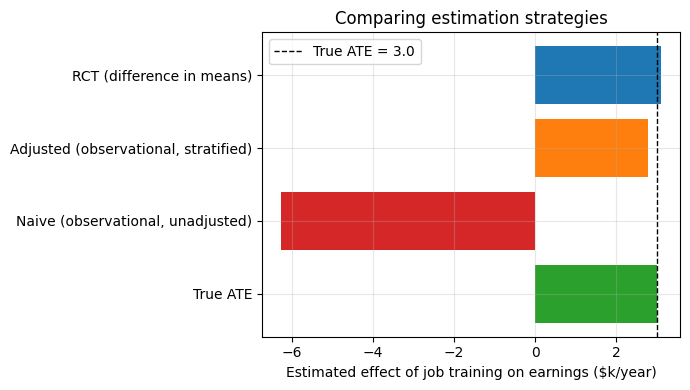

In [10]:

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4']
ax.barh(comparison['Method'], comparison['Estimate'], color=colors)
ax.axvline(TRUE_ATE, color='black', linestyle='--', linewidth=1,
           label=f'True ATE = {TRUE_ATE}')
ax.set_xlabel('Estimated effect of job training on earnings ($k/year)')
ax.set_title('Comparing estimation strategies')
ax.legend()
plt.tight_layout()
plt.show()



## 6. Bonus: a spurious correlation, economics edition

Section 1.4 of the book shows arcade revenue vs. computer-science PhDs
(correlation ≈ 0.98, no causal link — both driven by population growth).
Let's build an economics-flavored version: **ice-cream sales** and **the
stock market index**, both driven by a hidden third factor — the overall
size/wealth of the economy over time.


In [11]:

np.random.seed(7)
years = np.arange(2000, 2020)
economy_size = 100 + 4 * (years - 2000) + np.random.normal(0, 1, len(years))

ice_cream_sales = 5 + 0.08 * (economy_size - 100) + np.random.normal(0, 0.3, len(years))   # $ millions
stock_index     = 1000 + 25 * (economy_size - 100) + np.random.normal(0, 15, len(years))    # index points

spurious = pd.DataFrame({'year': years, 'ice_cream_sales': ice_cream_sales,
                          'stock_index': stock_index})
corr = np.corrcoef(spurious.ice_cream_sales, spurious.stock_index)[0, 1]
print(f"Correlation between ice-cream sales and the stock index: {corr:.3f}")


Correlation between ice-cream sales and the stock index: 0.978



A correlation this high might tempt a careless analyst to say "ice-cream
sales predict the stock market" (or vice versa) — but both are simply
riding the same underlying trend in overall economic activity. Just like
`Population -> Revenue` and `Population -> Doctorates` in Figure 1.4 of the
book, here `Economy size -> Ice-cream sales` and `Economy size -> Stock index`
is the real structure:

```
              Economy size
              /          \
             v            v
    Ice-cream sales    Stock index
```

No causal arrow runs between ice-cream sales and the stock index at all.



## 7. Conditional expectations recap

Everything above relied on one core statistical object from section 1.5.2:
the **conditional expectation** `E[earnings | treatment, experience]`. Let's
compute it directly as a table, the same way the book builds table 1.1–1.4
by hand.


In [12]:

cond_exp = (
    obs.assign(experience_group=pd.cut(obs.experience, bins=[0, 5, 10, 15, 20],
                                        labels=['0-5', '5-10', '10-15', '15-20']))
       .groupby(['experience_group', 'treatment'], observed=True)['earnings']
       .mean()
       .unstack('treatment')
       .rename(columns={0: 'E[earnings | control]', 1: 'E[earnings | treated]'})
)
cond_exp['within-group effect'] = (cond_exp['E[earnings | treated]']
                                    - cond_exp['E[earnings | control]'])
cond_exp


treatment,E[earnings | control],E[earnings | treated],within-group effect
experience_group,,,
0-5,24.108319,26.369667,2.261348
5-10,31.010253,33.467888,2.457635
10-15,37.644941,39.488815,1.843874
15-20,44.679690,47.121284,2.441594



Within every experience band, the treated group earns roughly **$3k more**
than the control group — matching the true effect we built into the data.
This is the practical payoff of "adjusting for confounders": once you hold
the confounder fixed, the remaining difference is (an estimate of) the
causal effect.



## 8. Exercises — extend this project

Try these to deepen your understanding (all doable with what's defined
above):

1. **Add a second confounder.** Add `education_years`, which also affects
   both enrollment probability and earnings. Does the simple 1-D
   stratification from Section 4 still fully remove the bias? Why might
   you need many more bins (or a regression-based adjustment) as the
   number of confounders grows?
2. **Vary the sample size.** Rerun the RCT simulation with `n = 100` instead
   of `5000`. How much does the estimated ATE bounce around across
   different random seeds? This connects to section 1.3.4's discussion of
   why we need confidence intervals, not just point estimates.
3. **Break "no confounders in RCTs."** Modify the RCT simulation so that
   `prob_treatment` still depends slightly on `experience` (e.g., a
   "randomized" trial with imperfect compliance). Does the simple
   difference-in-means become biased again?
4. **External validity.** Suppose the RCT only recruited unemployed people
   willing to travel to a training center (section 1.3.5's point about lack
   of external validity). Simulate this by restricting `rct` to
   `experience < 8`, recompute the ATE, and discuss whether this estimate
   would generalize to the full workforce.
5. **Real-world connection.** Look up LaLonde's (1986) National Supported
   Work (NSW) Demonstration dataset — the real-world example this project
   is inspired by — and compare its structure to the DAG we used here.

## Summary

- Observational job-training data is confounded by prior work experience:
  naive comparisons underestimate/misstate the program's true effect.
- Adjusting for the confounder (stratification, and later — regression /
  the adjustment formula) recovers an estimate close to the truth.
- A properly randomized experiment removes confounding by design; the
  simple difference in means is already unbiased.
- Two variables can be highly correlated purely because of a shared
  underlying driver, with no causal link between them at all.
